<a href="https://colab.research.google.com/github/Nois12/AIFFEL_quest_rs/blob/main/Exploration/Ex08/news_summarization_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# News Summarization

- Step 1. 데이터 수집
- Step 2. 데이터 전처리하기 (추상적 요약)
- Step 3. 어텐션 메커니즘 사용하기 (추상적 요약)
- Step 4. 실제 결과와 요약문 비교하기 (추상적 요약)
- Step 5. Summa를 이용해서 추출적 요약해보기 + 두 결과 비교

In [ ]:
!pip install --upgrade summa
!pip install --upgrade nltk
!pip install lxml
!pip install beautifulsoup4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for summa: filename=summa-1.2.0-py3-none-any.whl size=54387 sha256=d6d29cc87933cba0cb96d3728134adcf80c4d6e7a99c552740d153251d2f78c3
  Stored in directory: /root/.cache/pip/wheels/70/26/84/58df5a55ebde6fd802666b6ac0b86909ecd018a2702b89d13c
Successfully built summa
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 33.1 MB/s eta 0:00:00
  Attempting uninstall: nltk
    Found existing installation: nltk 3.9.1
    Uninstalling nltk-3.9.1:
      Successfully uninstalled nltk-3.9.1


In [ ]:
import nltk
# 클라우드 실습 환경 프록시 보안 정책으로 nltk 데이터 다운로드가 막히는 문제 우회 (download 호출 전에 위치)
nltk.pathsec.ALLOW_PROXIED_FETCH = True
nltk.download('stopwords')

import numpy as np
import pandas as pd
import os
import re
import html
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from bs4 import BeautifulSoup

import torch
from collections import Counter
from tqdm import tqdm
from tqdm.contrib.concurrent import process_map

from importlib.metadata import version
import nltk
import summa
from summa.summarizer import summarize as summa_summarize

import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence

print(nltk.__version__)
print(torch.__version__)
print(pd.__version__)
print(version('summa'))

import urllib.request
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='bs4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


3.10.3
2.11.0+cu128
2.2.2
1.2.0


## Step 1. 데이터 수집

In [ ]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/sunnysai12345/News_Summary/master/news_summary_more.csv", filename="news_summary_more.csv")
data = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')
print('전체 샘플수 :', (len(data)))

전체 샘플수 : 98401


In [ ]:
data.head()


,headlines,text
0,upGrad learner switches to career in ML & Al w...,"Saurav Kant, an alumnus of upGrad and IIIT-B's..."
1,Delhi techie wins free food from Swiggy for on...,Kunal Shah's credit card bill payment platform...
2,New Zealand end Rohit Sharma-led India's 12-ma...,New Zealand defeated India by 8 wickets in the...
3,Aegon life iTerm insurance plan helps customer...,"With Aegon Life iTerm Insurance plan, customer..."
4,"Have known Hirani for yrs, what if MeToo claim...",Speaking about the sexual harassment allegatio...


In [ ]:
data = data[['text', 'headlines']]
data['text_raw'] = data['text']  # 추출적 요약를 위한 원문 백업
data.sample(10)

,text,headlines,text_raw
5503,Two teachers were injured when unidentified as...,"Goons open fire at school in West Bengal, 2 te...",Two teachers were injured when unidentified as...
86564,Veteran actor Dharmendra has said that he won'...,My life is not worth a biopic or a book: Dharm...,Veteran actor Dharmendra has said that he won'...
46757,A Dublin hotel offers pastries and cakes inspi...,Dublin hotel offers food inspired by its own a...,A Dublin hotel offers pastries and cakes inspi...
46165,Talking about their process of developing and ...,We don't believe in using customers as laborat...,Talking about their process of developing and ...
32268,A nearly 66-foot-deep sinkhole has opened up o...,66-foot-deep sinkhole opens up on New Zealand ...,A nearly 66-foot-deep sinkhole has opened up o...
17516,Investor wealth has surged by over Ã¢ÂÂ¹12 la...,Investor wealth surges by Ã¢ÂÂ¹12 lakh crore ...,Investor wealth has surged by over Ã¢ÂÂ¹12 la...
77619,Delhi Commission for Women (DCW) chief Swati M...,Delhi Women Commission chief suggests body cam...,Delhi Commission for Women (DCW) chief Swati M...
85184,If the semi-final matchups of the Champions Tr...,What happens if CT semi-finals get washed out ...,If the semi-final matchups of the Champions Tr...
38413,New Zealand Women's 17-year-old spinner Amelia...,17-yr-old hits 232*(145) in an ODI to break 21...,New Zealand Women's 17-year-old spinner Amelia...
47013,Former Gitanjali Gems Managing Director Santos...,Choksi threatened to trap me in fraud case: Ex...,Former Gitanjali Gems Managing Director Santos...


## Step 2. 데이터 전처리하기 (추상적 요약)

In [ ]:
print('text 열에서 중복을 배제한 유일한 샘플의 수 :', data['text'].nunique())
print('headlines 열에서 중복을 배제한 유일한 샘플의 수 :', data['headlines'].nunique())

text 열에서 중복을 배제한 유일한 샘플의 수 : 98360
headlines 열에서 중복을 배제한 유일한 샘플의 수 : 98280


In [ ]:
data.drop_duplicates(subset = ['text'], inplace=True)
print('전체 샘플수 :', (len(data)))

전체 샘플수 : 98360


In [ ]:
print(data.isnull().sum())

text         0
headlines    0
text_raw     0
dtype: int64


In [ ]:
data.dropna(axis=0, inplace=True)
print('전체 샘플수 :', (len(data)))

전체 샘플수 : 98360


In [ ]:
contractions = {"ain't": "is not", "aren't": "are not","can't": "cannot", "'cause": "because", "could've": "could have", "couldn't": "could not",
                           "didn't": "did not",  "doesn't": "does not", "don't": "do not", "hadn't": "had not", "hasn't": "has not", "haven't": "have not",
                           "he'd": "he would","he'll": "he will", "he's": "he is", "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is",
                           "I'd": "I would", "I'd've": "I would have", "I'll": "I will", "I'll've": "I will have","I'm": "I am", "I've": "I have", "i'd": "i would",
                           "i'd've": "i would have", "i'll": "i will",  "i'll've": "i will have","i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would",
                           "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have","it's": "it is", "let's": "let us", "ma'am": "madam",
                           "mayn't": "may not", "might've": "might have","mightn't": "might not","mightn't've": "might not have", "must've": "must have",
                           "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have","o'clock": "of the clock",
                           "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not", "sha'n't": "shall not", "shan't've": "shall not have",
                           "she'd": "she would", "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have", "she's": "she is",
                           "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have", "so've": "so have","so's": "so as",
                           "this's": "this is","that'd": "that would", "that'd've": "that would have", "that's": "that is", "there'd": "there would",
                           "there'd've": "there would have", "there's": "there is", "here's": "here is","they'd": "they would", "they'd've": "they would have",
                           "they'll": "they will", "they'll've": "they will have", "they're": "they are", "they've": "they have", "to've": "to have",
                           "wasn't": "was not", "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have", "we're": "we are",
                           "we've": "we have", "weren't": "were not", "what'll": "what will", "what'll've": "what will have", "what're": "what are",
                           "what's": "what is", "what've": "what have", "when's": "when is", "when've": "when have", "where'd": "where did",
                           "where's": "where is", "where've": "where have", "who'll": "who will", "who'll've": "who will have", "who's": "who is",
                           "who've": "who have", "why's": "why is", "why've": "why have", "will've": "will have", "won't": "will not",
                           "won't've": "will not have", "would've": "would have", "wouldn't": "would not", "wouldn't've": "would not have",
                           "y'all": "you all", "y'all'd": "you all would","y'all'd've": "you all would have","y'all're": "you all are",
                           "y'all've": "you all have","you'd": "you would", "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have",
                           "you're": "you are", "you've": "you have"}

In [ ]:
print('불용어 개수 :', len(stopwords.words('english') ))
print(stopwords.words('english'))

불용어 개수 : 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "

In [ ]:
HTML_CLEANER = re.compile("<[^>]*>")  # BeautifulSoup 대신 사용할 태그 제거 정규식
PAREN_CLEANER = re.compile(r"\([^)]*\)")
QUOTE_CLEANER = re.compile('"')
POSSESSIVE_CLEANER = re.compile(r"'s\b")
NON_ALPHA_CLEANER = re.compile("[^a-zA-Z]")
M_CLEANER = re.compile("[m]{2,}")

stop_words = set(stopwords.words("english"))

def preprocess_sentence(sentence, remove_stopwords=True):
    sentence = sentence.lower()  # 텍스트 소문자화

    # BeautifulSoup 대신 정규식 + html.unescape 사용
    sentence = HTML_CLEANER.sub("", sentence)
    sentence = html.unescape(sentence)  # &amp; 나 &lt; 같은 html 엔티티 변환

    sentence = PAREN_CLEANER.sub("", sentence)  # 괄호 제거
    sentence = QUOTE_CLEANER.sub("", sentence)  # 쌍따옴표 제거

    sentence = " ".join(
        [contractions[t] if t in contractions else t for t in sentence.split()]
    )

    sentence = POSSESSIVE_CLEANER.sub("", sentence)  # 소유격 제거
    sentence = NON_ALPHA_CLEANER.sub(" ", sentence)  # 영어 외 문자 공백 변환
    sentence = M_CLEANER.sub("mm", sentence)  # m 연속 제거

    words = sentence.split()

    # 불용어 제거 (Set을 사용한 초고속 필터링)
    if remove_stopwords:
        tokens = " ".join(
            word for word in words if word not in stop_words and len(word) > 1
        )
    else:
        tokens = " ".join(word for word in words if len(word) > 1)

    return tokens

In [ ]:
temp_text = data['text'].iloc[0]
temp_headline = data['headlines'].iloc[0]

print("text: ", preprocess_sentence(temp_text))
print("headlines:", preprocess_sentence(temp_headline, False))  # 불용어를 제거하지 않음.

text:  saurav kant alumnus upgrad iiit pg program machine learning artificial intelligence sr systems engineer infosys almost years work experience program upgrad degree career support helped transition data scientist tech mahindra salary hike upgrad online power learning powered lakh careers
headlines: upgrad learner switches to career in ml al with salary hike


In [ ]:
clean_text = [preprocess_sentence(sentence) for sentence in tqdm(data['text'])]
print("text 전처리 후 결과: ", clean_text[:5])

clean_headlines = [preprocess_sentence(sentence, remove_stopwords=False) for sentence in tqdm(data['headlines'])]
print("headlines 전처리 후 결과: ", clean_headlines[:5])

100%|██████████| 98360/98360 [00:12<00:00, 7636.17it/s] 


text 전처리 후 결과:  ['saurav kant alumnus upgrad iiit pg program machine learning artificial intelligence sr systems engineer infosys almost years work experience program upgrad degree career support helped transition data scientist tech mahindra salary hike upgrad online power learning powered lakh careers', 'kunal shah credit card bill payment platform cred gave users chance win free food swiggy one year pranav kaushik delhi techie bagged reward spending cred coins users get one cred coin per rupee bill paid used avail rewards brands like ixigo bookmyshow ubereats cult fit', 'new zealand defeated india wickets fourth odi hamilton thursday win first match five match odi series india lost international match rohit sharma captaincy consecutive victories dating back march match witnessed india getting seventh lowest total odi cricket history', 'aegon life iterm insurance plan customers enjoy tax benefits premiums paid save taxes plan provides life cover age years also customers options insur

100%|██████████| 98360/98360 [00:01<00:00, 58779.31it/s]

headlines 전처리 후 결과:  ['upgrad learner switches to career in ml al with salary hike', 'delhi techie wins free food from swiggy for one year on cred', 'new zealand end rohit sharma led india match winning streak', 'aegon life iterm insurance plan helps customers save tax', 'have known hirani for yrs what if metoo claims are not true sonam']


In [ ]:
data['text'] = clean_text
data['headlines'] = clean_headlines

# 빈 값을 Null 값으로 변환
data.replace('', np.nan, inplace=True)

In [ ]:
data.isnull().sum()

,0
text,0
headlines,0
text_raw,0


In [ ]:
data.dropna(axis=0, inplace=True)
print('전체 샘플수 :', (len(data)))

전체 샘플수 : 98360


훈련테스트 테스트 데이터 나누기

텍스트의 최소 길이 : 1
텍스트의 최대 길이 : 60
텍스트의 평균 길이 : 35.09968483123221
요약의 최소 길이 : 1
요약의 최대 길이 : 16
요약의 평균 길이 : 9.299532330215534


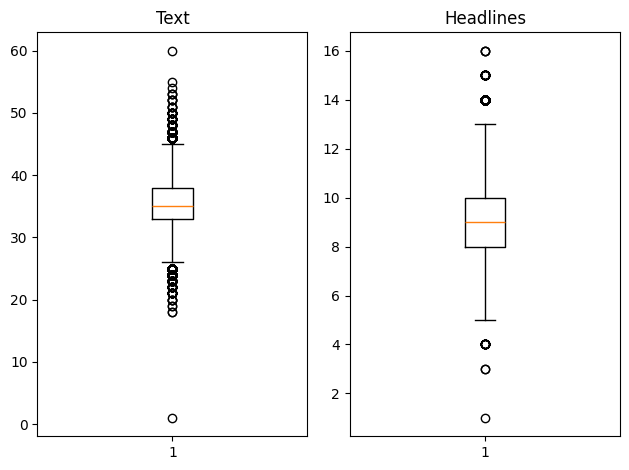

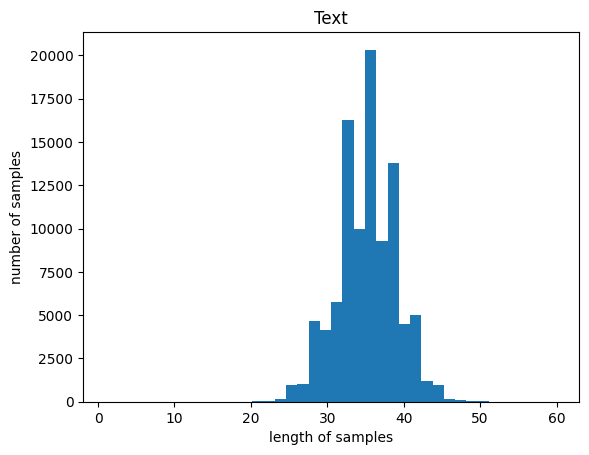

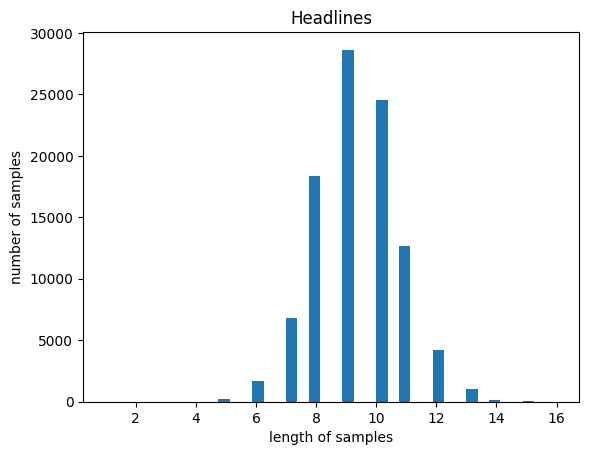

In [ ]:
text_len = [len(s.split()) for s in data['text']]
summary_len = [len(s.split()) for s in data['headlines']]

print('텍스트의 최소 길이 : {}'.format(np.min(text_len)))
print('텍스트의 최대 길이 : {}'.format(np.max(text_len)))
print('텍스트의 평균 길이 : {}'.format(np.mean(text_len)))
print('요약의 최소 길이 : {}'.format(np.min(summary_len)))
print('요약의 최대 길이 : {}'.format(np.max(summary_len)))
print('요약의 평균 길이 : {}'.format(np.mean(summary_len)))

plt.subplot(1,2,1)
plt.boxplot(text_len)
plt.title('Text')
plt.subplot(1,2,2)
plt.boxplot(summary_len)
plt.title('Headlines')
plt.tight_layout()
plt.show()

plt.title('Text')
plt.hist(text_len, bins = 40)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

plt.title('Headlines')
plt.hist(summary_len, bins = 40)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

In [ ]:
text_max_len = 60
summary_max_len = 15

In [ ]:
def below_threshold_len(max_len, nested_list):
  cnt = 0
  for s in nested_list:
    if(len(s.split()) <= max_len):
        cnt = cnt + 1
  print('전체 샘플 중 길이가 %s 이하인 샘플의 비율: %s'%(max_len, (cnt / len(nested_list))))

In [ ]:
below_threshold_len(text_max_len, data['text'])
below_threshold_len(summary_max_len, data['headlines'])

전체 샘플 중 길이가 60 이하인 샘플의 비율: 1.0
전체 샘플 중 길이가 15 이하인 샘플의 비율: 0.9999694997966653


In [ ]:
data = data[data['text'].apply(lambda x: len(x.split()) <= text_max_len)]
data = data[data['headlines'].apply(lambda x: len(x.split()) <= summary_max_len)]

print('전체 샘플수 :', (len(data)))

전체 샘플수 : 98357


In [ ]:
# 요약 데이터에는 시작 토큰과 종료 토큰을 추가
data['decoder_input'] = data['headlines'].apply(lambda x : 'sostoken '+ x)
data['decoder_target'] = data['headlines'].apply(lambda x : x + ' eostoken')
data.head()

,text,headlines,text_raw,decoder_input,decoder_target
0,saurav kant alumnus upgrad iiit pg program mac...,upgrad learner switches to career in ml al wit...,"Saurav Kant, an alumnus of upGrad and IIIT-B's...",sostoken upgrad learner switches to career in ...,upgrad learner switches to career in ml al wit...
1,kunal shah credit card bill payment platform c...,delhi techie wins free food from swiggy for on...,Kunal Shah's credit card bill payment platform...,sostoken delhi techie wins free food from swig...,delhi techie wins free food from swiggy for on...
2,new zealand defeated india wickets fourth odi ...,new zealand end rohit sharma led india match w...,New Zealand defeated India by 8 wickets in the...,sostoken new zealand end rohit sharma led indi...,new zealand end rohit sharma led india match w...
3,aegon life iterm insurance plan customers enjo...,aegon life iterm insurance plan helps customer...,"With Aegon Life iTerm Insurance plan, customer...",sostoken aegon life iterm insurance plan helps...,aegon life iterm insurance plan helps customer...
4,speaking sexual harassment allegations rajkuma...,have known hirani for yrs what if metoo claims...,Speaking about the sexual harassment allegatio...,sostoken have known hirani for yrs what if met...,have known hirani for yrs what if metoo claims...


In [ ]:
encoder_input = np.array(data['text']) # 인코더의 입력
decoder_input = np.array(data['decoder_input']) # 디코더의 입력
decoder_target = np.array(data['decoder_target']) # 디코더의 레이블
text_raw_arr = np.array(data['text_raw']) # 추출적 요약를 위한 원문
headlines_raw_arr = np.array(data['headlines'])

In [ ]:
indices = np.arange(encoder_input.shape[0])
np.random.shuffle(indices)
print(indices)

[74356 22989 69959 ... 65189 25729 53203]


In [ ]:
encoder_input = encoder_input[indices]
decoder_input = decoder_input[indices]
decoder_target = decoder_target[indices]
text_raw_arr = text_raw_arr[indices]
headlines_raw_arr = headlines_raw_arr[indices]

In [ ]:
n_of_val = int(len(encoder_input)*0.2)
print('테스트 데이터의 수 :', n_of_val)

테스트 데이터의 수 : 19671


In [ ]:
encoder_input_train = encoder_input[:-n_of_val]
decoder_input_train = decoder_input[:-n_of_val]
decoder_target_train = decoder_target[:-n_of_val]

encoder_input_test = encoder_input[-n_of_val:]
decoder_input_test = decoder_input[-n_of_val:]
decoder_target_test = decoder_target[-n_of_val:]

text_raw_test = text_raw_arr[-n_of_val:]       # 추출적 요약 비교용 원문
headlines_raw_test = headlines_raw_arr[-n_of_val:] # 추출적 요약 비교용 실제 헤드라인

print('훈련 데이터의 개수 :', len(encoder_input_train))
print('훈련 레이블의 개수 :', len(decoder_input_train))
print('테스트 데이터의 개수 :', len(encoder_input_test))
print('테스트 레이블의 개수 :', len(decoder_input_test))

훈련 데이터의 개수 : 78686
훈련 레이블의 개수 : 78686
테스트 데이터의 개수 : 19671
테스트 레이블의 개수 : 19671


인코딩

In [ ]:
def src_tokenizer(text): # 토크나이저 정의
    text = text.lower()  # 소문자로 변환
    text = re.sub(r"[^a-zA-Z0-9]+", " ", text)  # 특수문자 제거
    return text.split()  # 공백 기준 토큰화

def build_vocab(texts):
    vocab = {"<PAD>": 0, "<UNK>": 1}  # 패딩과 UNK 토큰 추가
    word_counter = Counter()

    for text in texts:
        word_counter.update(src_tokenizer(text))  # 단어 빈도수 계산

    # 단어 집합 생성 (빈도가 높은 순서대로)
    for word, _ in word_counter.most_common():
        if word not in vocab:
            vocab[word] = len(vocab)

    return vocab

src_vocab = build_vocab(encoder_input_train) # 입력된 데이터로부터 단어 집합 생성

In [ ]:
threshold = 7

# 전처리된 데이터 사용
text_data = data['text'].tolist()
summary_data = data['headlines'].tolist()
# 단어 빈도수 계산
word_counter = Counter()
for text in text_data:
    word_counter.update(text.split())

total_cnt = len(word_counter)  # 전체 단어 개수
total_freq = sum(word_counter.values())  # 전체 단어 등장 횟수
rare_cnt = sum(1 for count in word_counter.values() if count < threshold)  # 희귀 단어 개수
rare_freq = sum(count for count in word_counter.values() if count < threshold)  # 희귀 단어 등장 횟수

print('단어 집합(vocabulary)의 크기 :', total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s'%(threshold - 1, rare_cnt))
print('단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 %s'%(total_cnt - rare_cnt))
print("단어 집합에서 희귀 단어의 비율:", (rare_cnt / total_cnt)*100)
print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율:", (rare_freq / total_freq)*100)

단어 집합(vocabulary)의 크기 : 76334
등장 빈도가 6번 이하인 희귀 단어의 수: 51777
단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 24557
단어 집합에서 희귀 단어의 비율: 67.82953860664972
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 3.0340045569593856


In [ ]:
src_vocab_size = 8000

def build_limited_vocab(texts, vocab_size):
    vocab = {"<PAD>": 0, "<UNK>": 1}  # 패딩과 UNK 토큰 추가
    word_counter = Counter()

    for text in texts:
        word_counter.update(src_tokenizer(text))  # 단어 빈도수 계산

    # 빈도가 높은 상위 vocab_size - 2개 단어만 선택 (PAD, UNK 포함)
    for word, _ in word_counter.most_common(vocab_size - 2):
        vocab[word] = len(vocab)

    return vocab

src_vocab = build_limited_vocab(encoder_input_train, src_vocab_size)

In [ ]:
def text_to_sequence(texts, vocab):
    sequences = []
    for text in texts:
        sequence = [vocab.get(word, vocab["<UNK>"]) for word in src_tokenizer(text)]
        sequences.append(sequence)
    return sequences

# 텍스트 데이터 정수 시퀀스로 변환
encoder_input_train_seq = text_to_sequence(encoder_input_train, src_vocab)
encoder_input_test_seq = text_to_sequence(encoder_input_test, src_vocab)

# 잘 진행되었는지 샘플 출력
print(encoder_input_train_seq[:3])
print(encoder_input_test_seq[:3])

[[16, 2507, 1, 1747, 252, 4255, 4649, 29, 80, 1147, 855, 5233, 2436, 160, 379, 1, 2507, 2436, 160, 34, 68, 4649, 2087, 119, 6859, 5717, 452, 5671, 5137, 7662, 33, 39, 1747, 1, 143, 24, 1578, 4649, 2051], [453, 448, 51, 6061, 166, 81, 939, 243, 4120, 1752, 499, 6429, 1, 4927, 606, 805, 4121, 3110, 243, 499, 585, 1, 2518, 4848, 5, 6061, 816, 117, 840, 1104, 3306, 312, 81, 1, 180, 2614, 11, 1], [33, 60, 2, 24, 458, 4349, 4734, 406, 1, 706, 2473, 1644, 1902, 931, 1, 2159, 994, 1572, 39, 9, 1, 1854, 11, 33, 650, 1682, 1, 42, 258, 1644, 2473]]
[[12, 3219, 6658, 4790, 186, 4902, 93, 757, 211, 2704, 20, 2831, 128, 1602, 104, 251, 1119, 141, 114, 1666, 1483, 4, 14, 158, 337, 187, 1840, 2154, 2139, 1119, 141, 2372, 183, 20, 144, 18], [571, 431, 410, 86, 2390, 2962, 121, 207, 2, 24, 359, 170, 21, 468, 1916, 620, 837, 79, 486, 2535, 468, 7202, 1179, 275, 1, 468, 1, 757, 837, 509, 229, 2], [325, 2646, 4436, 973, 1, 1, 4610, 4436, 80, 1, 49, 2, 228, 1, 1, 84, 5459, 37, 2729, 4457, 50, 111, 47, 3627,

In [ ]:
def tar_tokenizer(text):
    text = text.lower()  # 소문자로 변환
    text = re.sub(r"[^a-zA-Z0-9]+", " ", text)  # 특수문자 제거
    return text.split()  # 공백 기준 토큰화

tar_vocab = build_vocab(decoder_input_train)

In [ ]:
threshold = 6

word_counter = Counter()
for text in decoder_input_train:
    word_counter.update(tar_tokenizer(text))  # 각 문장의 단어 빈도 계산

# 전체 단어 개수 및 등장 빈도 계산
total_cnt = len(word_counter)  # 전체 단어 개수
total_freq = sum(word_counter.values())  # 전체 단어 등장 횟수
rare_cnt = sum(1 for count in word_counter.values() if count < threshold)  # 희귀 단어 개수
rare_freq = sum(count for count in word_counter.values() if count < threshold)  # 희귀 단어 등장 횟수

print('단어 집합(vocabulary)의 크기 :', total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s'%(threshold - 1, rare_cnt))
print('단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 %s'%(total_cnt - rare_cnt))
print("단어 집합에서 희귀 단어의 비율:", (rare_cnt / total_cnt)*100)
print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율:", (rare_freq / total_freq)*100)

단어 집합(vocabulary)의 크기 : 30110
등장 빈도가 5번 이하인 희귀 단어의 수: 19698
단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 10412
단어 집합에서 희귀 단어의 비율: 65.42012620391895
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 4.653461924874169


In [ ]:
tar_vocab_size = 2000
tar_vocab = build_limited_vocab(decoder_input_train + decoder_target_train, tar_vocab_size)

# 텍스트 시퀀스를 정수 시퀀스로 변환
decoder_input_train_seq = text_to_sequence(decoder_input_train, tar_vocab)
decoder_target_train_seq = text_to_sequence(decoder_target_train, tar_vocab)
decoder_input_test_seq = text_to_sequence(decoder_input_test, tar_vocab)
decoder_target_test_seq = text_to_sequence(decoder_target_test, tar_vocab)

# 잘 변환되었는지 확인
print('input')
print('input ',decoder_input_train_seq[:5])
print('target')
print('decoder ',decoder_target_train_seq[:5])

input
input  [[2, 1, 8, 36, 37, 1, 599, 56, 1], [2, 706, 1, 1, 14, 1, 1409, 7, 499, 1, 372], [2, 154, 4, 223, 1, 251, 32, 305, 1208, 308], [2, 36, 436, 478, 856, 15, 270, 5, 107, 1631], [2, 203, 146, 60, 94, 1, 1, 23, 8, 1, 1568, 643, 638]]
target
decoder  [[1, 8, 36, 37, 1, 599, 56, 1, 3], [706, 1, 1, 14, 1, 1409, 7, 499, 1, 372, 3], [154, 4, 223, 1, 251, 32, 305, 1208, 308, 3], [36, 436, 478, 856, 15, 270, 5, 107, 1631, 3], [203, 146, 60, 94, 1, 1, 23, 8, 1, 1568, 643, 638, 3]]


In [ ]:
drop_train = [index for index, sentence in enumerate(decoder_input_train) if len(sentence.split()) == 1]
drop_test = [index for index, sentence in enumerate(decoder_input_test) if len(sentence.split()) == 1]

print('삭제할 훈련 데이터의 개수 :', len(drop_train))
print('삭제할 테스트 데이터의 개수 :', len(drop_test))

encoder_input_train_seq = [sentence for index, sentence in enumerate(encoder_input_train_seq) if index not in drop_train]
decoder_input_train_seq = [sentence for index, sentence in enumerate(decoder_input_train_seq) if index not in drop_train]
decoder_target_train_seq = [sentence for index, sentence in enumerate(decoder_target_train_seq) if index not in drop_train]

encoder_input_test_seq = [sentence for index, sentence in enumerate(encoder_input_test_seq) if index not in drop_test]
decoder_input_test_seq = [sentence for index, sentence in enumerate(decoder_input_test_seq) if index not in drop_test]
decoder_target_test_seq = [sentence for index, sentence in enumerate(decoder_target_test_seq) if index not in drop_test]

text_raw_test = [s for index, s in enumerate(text_raw_test) if index not in drop_test]         # 추출적 요약을 위한 원문도 함께 제거
headlines_raw_test = [s for index, s in enumerate(headlines_raw_test) if index not in drop_test] # 추출적 요약을 위한 실제 헤드라인도 함께 제거

print('훈련 데이터의 개수 :', len(encoder_input_train_seq))
print('훈련 레이블의 개수 :', len(decoder_input_train_seq))
print('테스트 데이터의 개수 :', len(encoder_input_test_seq))
print('테스트 레이블의 개수 :', len(decoder_input_test_seq))

삭제할 훈련 데이터의 개수 : 0
삭제할 테스트 데이터의 개수 : 0
훈련 데이터의 개수 : 78686
훈련 레이블의 개수 : 78686
테스트 데이터의 개수 : 19671
테스트 레이블의 개수 : 19671


패딩

In [ ]:
# 텐서 변환 함수 (리스트 → PyTorch 텐서)
def convert_to_tensor(sequences):
    return [torch.tensor(seq, dtype=torch.long) for seq in sequences]

# 패딩 적용 함수 (PyTorch `pad_sequence()` 활용)
def pad_sequences_pytorch(sequences, maxlen, padding_value=0):
    sequences = convert_to_tensor(sequences)  # 리스트를 텐서로 변환
    padded_seqs = pad_sequence(sequences, batch_first=True, padding_value=padding_value)  # 패딩 적용
    if padded_seqs.shape[1] < maxlen:  # 배치 내 최대 길이가 maxlen보다 짧은 경우를 대비해 오른쪽에 0으로 채움
        pad_extra = torch.zeros((padded_seqs.shape[0], maxlen - padded_seqs.shape[1]), dtype=torch.long)
        padded_seqs = torch.cat([padded_seqs, pad_extra], dim=1)
    return padded_seqs[:, :maxlen]  # maxlen 길이로 자르기 (최대 길이 초과 방지)

# 패딩 적용
encoder_input_train = pad_sequences_pytorch(encoder_input_train_seq, maxlen=text_max_len)
encoder_input_test = pad_sequences_pytorch(encoder_input_test_seq, maxlen=text_max_len)
decoder_input_train = pad_sequences_pytorch(decoder_input_train_seq, maxlen=summary_max_len)
decoder_target_train = pad_sequences_pytorch(decoder_target_train_seq, maxlen=summary_max_len)
decoder_input_test = pad_sequences_pytorch(decoder_input_test_seq, maxlen=summary_max_len)
decoder_target_test = pad_sequences_pytorch(decoder_target_test_seq, maxlen=summary_max_len)

모델 설계

In [ ]:
# 인코더 설계 시작
embedding_dim = 128
hidden_size = 256
src_vocab_size = len(src_vocab)  # 단어 집합 크기

# 인코더
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4):
        super(Encoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_size, num_layers=num_layers,
            dropout=dropout, batch_first=True
        )

    def forward(self, x): # 인코더의 임베딩 층
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded)  # LSTM 실행
        return output, hidden, cell

# 인코더 모델 생성
encoder = Encoder(src_vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4)

In [ ]:
# 디코더 설계
class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, dropout=0.4, num_layers=3):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_size, num_layers=num_layers, dropout=dropout,
            batch_first=True
        )

    def forward(self, x, hidden, cell): # 디코더의 임베딩 층
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))  # 초기 상태를 인코더에서 전달받음
        return output, hidden, cell

# 디코더 모델 생성
tar_vocab_size = len(tar_vocab)
decoder = Decoder(tar_vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4)

In [ ]:
# 디코더의 출력층
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, vocab_size):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.softmax_layer = nn.Linear(hidden_size, vocab_size)  # 출력층 정의

    def forward(self, encoder_input, decoder_input):
        # 인코더 실행
        encoder_output, hidden, cell = self.encoder(encoder_input)

        # 디코더 실행
        decoder_output, _, _ = self.decoder(decoder_input, hidden, cell)

        # 출력층 적용
        output = self.softmax_layer(decoder_output)
        return output

## Step 3. 어텐션 메커니즘 사용하기 (추상적 요약)


In [ ]:
class Attention_dot(nn.Module):
    def __init__(self, hidden_size):
        super(Attention_dot, self).__init__()
        self.attn = nn.Linear(hidden_size, hidden_size)  # 어텐션 가중치
        self.v = nn.Linear(hidden_size, 1, bias=False)  # 어텐션 가중치 벡터

    def forward(self, decoder_output, encoder_outputs):
        attn_weights = torch.bmm(decoder_output, encoder_outputs.transpose(1, 2))
        attn_weights = F.softmax(attn_weights, dim=-1)  # 어텐션 가중치 정규화
        attn_out = torch.bmm(attn_weights, encoder_outputs)

        return attn_out

class Seq2SeqWithAttention(nn.Module):
    def __init__(self, encoder, decoder, vocab_size, hidden_size):
        super(Seq2SeqWithAttention, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.attention = Attention_dot(hidden_size)
        self.concat = nn.Linear(hidden_size * 2, hidden_size)  # 어텐션 결합
        self.output_layer = nn.Linear(hidden_size, vocab_size)  # 최종 출력층

    def forward(self, encoder_input, decoder_input):
        encoder_outputs, hidden, cell = self.encoder(encoder_input)
        decoder_outputs, _, _ = self.decoder(decoder_input, hidden, cell)

        # 어텐션 적용
        attn_out = self.attention(decoder_outputs, encoder_outputs)

        # 어텐션 결과와 디코더 출력 연결
        decoder_concat_output = torch.cat((decoder_outputs, attn_out), dim=-1)

        # 어텐션 결합 후 최종 출력
        decoder_concat_output = torch.tanh(self.concat(decoder_concat_output))
        output = self.output_layer(decoder_concat_output)

        return output

# 모델 생성
model = Seq2SeqWithAttention(encoder, decoder, tar_vocab_size, hidden_size)
print(model)

Seq2SeqWithAttention(
  (encoder): Encoder(
    (embedding): Embedding(8000, 128)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (decoder): Decoder(
    (embedding): Embedding(2000, 128)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (attention): Attention_dot(
    (attn): Linear(in_features=256, out_features=256, bias=True)
    (v): Linear(in_features=256, out_features=1, bias=False)
  )
  (concat): Linear(in_features=512, out_features=256, bias=True)
  (output_layer): Linear(in_features=256, out_features=2000, bias=True)
)


모델 훈련

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

# Hyperparameters
batch_size = 128
epochs = 30
learning_rate = 0.001
patience = 3

# 손실 함수 & 옵티마이저
criterion = nn.CrossEntropyLoss(ignore_index=0)  # 패딩 토큰 무시
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

# PyTorch DataLoader 설정
train_dataset = TensorDataset(encoder_input_train, decoder_input_train, decoder_target_train)
test_dataset = TensorDataset(encoder_input_test, decoder_input_test, decoder_target_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Using device: cuda


In [ ]:
train_losses = []
val_losses = []

# 학습 함수
def train_model(model, train_loader, test_loader, criterion, optimizer, epochs, patience):
    model.train()
    best_val_loss = float('inf')
    early_stop_counter = 0

    for epoch in range(epochs):
        total_loss = 0

        for encoder_input, decoder_input, target in train_loader:
            optimizer.zero_grad()

            # 정수형 변환
            encoder_input = encoder_input.to(device).long()
            decoder_input = decoder_input.to(device).long()
            target = target.to(device).long()

            # 모델 실행
            output = model(encoder_input, decoder_input)
            output = output.view(-1, output.shape[-1])
            target = target.view(-1)

            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Validation loss 계산
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for encoder_input, decoder_input, target in test_loader:
                encoder_input = encoder_input.to(device).long()
                decoder_input = decoder_input.to(device).long()
                target = target.to(device).long()

                output = model(encoder_input, decoder_input)
                output = output.view(-1, output.shape[-1])
                target = target.view(-1)
                loss = criterion(output, target)

                val_loss += loss.item()

        val_loss /= len(test_loader)
        val_losses.append(val_loss)
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_loss:.4f} | Val Loss: {val_loss:.4f}")

        # Early Stopping 조건
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

        model.train()

In [ ]:
%%time
# GPU 환경에서 학습하는 것을 권장합니다.-> validation loss가 더 이상 개선되지 않으면 학습 중단.
train_model(model, train_loader, test_loader, criterion, optimizer, epochs=epochs, patience=patience)

Epoch 1/30 | Train Loss: 4.8874 | Val Loss: 4.5827
Epoch 2/30 | Train Loss: 4.3212 | Val Loss: 4.0891
Epoch 3/30 | Train Loss: 3.9160 | Val Loss: 3.7634
Epoch 4/30 | Train Loss: 3.6207 | Val Loss: 3.5390
Epoch 5/30 | Train Loss: 3.4019 | Val Loss: 3.3754
Epoch 6/30 | Train Loss: 3.2305 | Val Loss: 3.2675
Epoch 7/30 | Train Loss: 3.0909 | Val Loss: 3.1843
Epoch 8/30 | Train Loss: 2.9765 | Val Loss: 3.1258
Epoch 9/30 | Train Loss: 2.8768 | Val Loss: 3.0788
Epoch 10/30 | Train Loss: 2.7887 | Val Loss: 3.0438
Epoch 11/30 | Train Loss: 2.7138 | Val Loss: 3.0212
Epoch 12/30 | Train Loss: 2.6441 | Val Loss: 3.0115
Epoch 13/30 | Train Loss: 2.5805 | Val Loss: 2.9883
Epoch 14/30 | Train Loss: 2.5222 | Val Loss: 2.9898
Epoch 15/30 | Train Loss: 2.4685 | Val Loss: 2.9885
Epoch 16/30 | Train Loss: 2.4200 | Val Loss: 2.9896
Early stopping triggered at epoch 16
CPU times: user 6min 51s, sys: 953 ms, total: 6min 52s
Wall time: 7min 28s


## Step 4. 실제 결과와 요약문 비교하기 (추상적 요약)

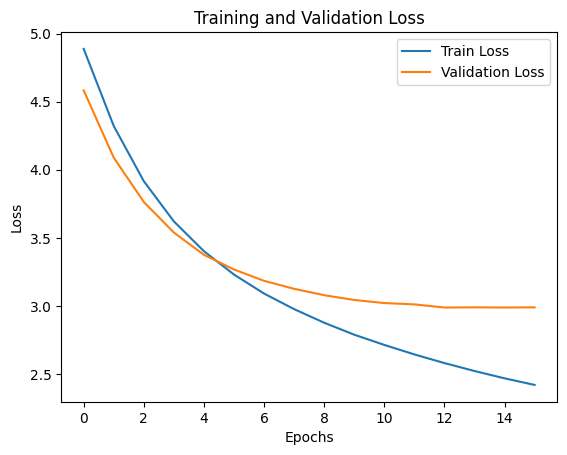

In [ ]:
plt.plot(range(len(train_losses)), train_losses, label='Train Loss')
plt.plot(range(len(val_losses)), val_losses, label='Validation Loss')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.show()

인퍼런스 모델 구현

In [ ]:
src_index_to_word = {idx: word for word, idx in src_vocab.items()} # 원문 단어 집합에서 정수 -> 단어를 얻음
tar_word_to_index = tar_vocab # 요약 단어 집합에서 단어 -> 정수를 얻음
tar_index_to_word = {idx: word for word, idx in tar_vocab.items()} # 요약 단어 집합에서 정수 -> 단어를 얻음

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
decoder.to(device)

# 인코더 설계
def encode_input(encoder, input_seq):
    encoder_outputs, hidden, cell = encoder(input_seq)
    return encoder_outputs, hidden, cell

In [ ]:
class DecoderWithAttention(nn.Module):
    def __init__(self, decoder, attention, hidden_size, vocab_size):
        super(DecoderWithAttention, self).__init__()
        self.decoder = decoder  # 기존 디코더
        self.attention = attention  # 어텐션 레이어
        self.concat = nn.Linear(hidden_size * 2, hidden_size)  # 어텐션 결합 레이어
        self.output_layer = nn.Linear(hidden_size, vocab_size)  # 최종 출력층
        self.softmax = nn.Softmax(dim=-1)  # 소프트맥스

    def forward(self, decoder_inputs, encoder_outputs, decoder_state_h, decoder_state_c):
        # 디코더 실행
        decoder_outputs, state_h, state_c = self.decoder(decoder_inputs, decoder_state_h, decoder_state_c)

        # 어텐션 적용
        attn_out = self.attention(decoder_outputs, encoder_outputs)

        # 어텐션과 디코더 출력 결합
        decoder_concat_output = torch.cat((decoder_outputs, attn_out), dim=-1)
        decoder_concat_output = torch.tanh(self.concat(decoder_concat_output))

        # 최종 출력층 적용
        decoder_outputs2 = self.softmax(self.output_layer(decoder_concat_output))

        return decoder_outputs2, state_h, state_c

# 학습된 모델의 어텐션/결합층/출력층 가중치를 그대로 사용해서 어텐션 디코더 구성
decoder_model = DecoderWithAttention(decoder, model.attention, hidden_size, tar_vocab_size)
decoder_model.concat = model.concat
decoder_model.output_layer = model.output_layer
decoder_model.to(device)
print(decoder_model)

DecoderWithAttention(
  (decoder): Decoder(
    (embedding): Embedding(2000, 128)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (attention): Attention_dot(
    (attn): Linear(in_features=256, out_features=256, bias=True)
    (v): Linear(in_features=256, out_features=1, bias=False)
  )
  (concat): Linear(in_features=512, out_features=256, bias=True)
  (output_layer): Linear(in_features=256, out_features=2000, bias=True)
  (softmax): Softmax(dim=-1)
)


In [ ]:
def decode_sequence(input_seq, encoder, decoder_model, tar_word_to_index, tar_index_to_word, text_max_len, summary_max_len, device):
    # 입력을 PyTorch Tensor로 변환
    input_seq = torch.tensor(input_seq, dtype=torch.long, device=device) if not torch.is_tensor(input_seq) else input_seq.to(device)

    # 인코더 실행하여 초기 상태(hidden, cell)와 전체 출력(encoder_outputs) 얻기
    with torch.no_grad():
        e_out, e_h, e_c = encode_input(encoder, input_seq)

    # SOS에 해당하는 토큰 생성
    target_seq = torch.zeros((1, 1), dtype=torch.long, device=device)
    target_seq[0, 0] = tar_word_to_index['sostoken']

    stop_condition = False
    decoded_sentence = ''

    while not stop_condition:
        # 어텐션 디코더 실행 (decoder_model을 사용해 실제로 어텐션을 적용)
        with torch.no_grad():
            output_tokens, h, c = decoder_model(target_seq, e_out, e_h, e_c)

        # 가장 높은 확률을 가진 단어 선택
        sampled_token_index = torch.argmax(output_tokens[0, -1, :]).item()
        sampled_token = tar_index_to_word.get(sampled_token_index, '<UNK>')

        if sampled_token != 'eostoken':
            decoded_sentence += ' ' + sampled_token

        # 종료 조건: <eos>에 도달하거나 최대 길이를 초과하면 중단
        if sampled_token == 'eostoken' or len(decoded_sentence.split()) >= (summary_max_len - 1):
            stop_condition = True

        # 길이가 1인 타겟 시퀀스를 업데이트
        target_seq = torch.zeros((1, 1), dtype=torch.long, device=device)
        target_seq[0, 0] = sampled_token_index

        # 상태 업데이트
        e_h, e_c = h, c

    return decoded_sentence.strip()

모델 테스트

In [ ]:
# 원문의 정수 시퀀스를 텍스트 시퀀스로 변환
def seq2text(input_seq):
    temp = ''
    for i in input_seq:
        key = int(i.item())  # PyTorch Tensor → int 변환
        if key != 0:  # 패딩(0) 제외
            temp = temp + src_index_to_word.get(key, "<UNK>") + ' '  # 안전한 조회
    return temp.strip()

# 요약문의 정수 시퀀스를 텍스트 시퀀스로 변환
def seq2summary(input_seq):
    temp = ''
    for i in input_seq:
        key = int(i.item())  # PyTorch Tensor → int 변환
        if key != 0 and key != tar_word_to_index['sostoken'] and key != tar_word_to_index['eostoken']:
            temp = temp + tar_index_to_word.get(key, "<UNK>") + ' '  # 안전한 조회
    return temp.strip()  # 양쪽 공백 제거

In [ ]:
%%time
for i in range(0, 10):
    print("원문 :", seq2text(encoder_input_test[i]))
    print("실제 요약 :", seq2summary(decoder_input_test[i]))
    input_seq = torch.tensor(encoder_input_test[i], dtype=torch.long, device=device).unsqueeze(0)
    print("예측 요약 :", decode_sequence(input_seq, encoder, decoder_model, tar_word_to_index, tar_index_to_word, text_max_len, summary_max_len, device))
    print("\n")

원문 : indian shuttler kidambi srikanth recently climbed second spot men singles world rankings set miss china open super series due leg injury year old back action week rest hong kong super series chance become world number one
실제 요약 : <UNK> to miss china open super series due to <UNK> <UNK>
예측 요약 : <UNK> <UNK> nd <UNK> in world open <UNK>


원문 : parents class boy found murdered ryan international school said would move supreme court cbi begin probe soon case still transferred cbi crucial evidence lost <UNK> cbi <UNK> spot soon victim father said
실제 요약 : will move sc if cbi <UNK> <UNK> probe kin of ryan victim
예측 요약 : parents <UNK> to be <UNK> in sc to probe ryan school


원문 : speaking reference manipur journalist <UNK> <UNK> detention manipur cm <UNK> singh said cannot <UNK> <UNK> national heroes like rani jhansi pm narendra modi abusing national heroes totally beyond freedom expression added <UNK> detained national security act criticising bjp led state government
실제 요약 : cannot <UNK>

<timed exec>:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).


예측 요약 : <UNK> <UNK> <UNK> <UNK> <UNK> cm <UNK> on <UNK> <UNK>


원문 : uber first employee ryan <UNK> stepping post senior vice president global operations <UNK> also held ceo post briefly co founder travis kalanick took <UNK> remain board director email employees said taken time reflect mistakes
실제 요약 : uber first employee ryan <UNK> resigns
예측 요약 : uber first employee <UNK> <UNK> as vp of <UNK>


원문 : animal rights organisation <UNK> india gift portrait rescued bull story written prince harry meghan markle occasion wedding bull currently <UNK> india maharashtra named <UNK> hybrid names meghan harry gift spread awareness animal cruelty
실제 요약 : <UNK> india to gift <UNK> <UNK> to uk royal couple
예측 요약 : <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK>


원문 : teaser fifty <UNK> freed final <UNK> fifty <UNK> <UNK> released <UNK> <UNK> <UNK> role christian grey <UNK> johnson return <UNK> <UNK> film based el james novel directed james <UNK> film scheduled valentine day release next year
실제 요약 : <UNK

## Step 5. Summa를 이용해서 추출적 요약

추출적 요약은 원문 문장 부호가 살아있어야 문장 단위로 분리가 가능하므로, Step2에서 전처리 전에 미리 백업해둔 `text_raw_test`(원문)를 사용한다.

In [ ]:
def extractive_summarize(raw_text, words=None, ratio=0.3):
    try:
        summary = summa_summarize(raw_text, ratio=ratio, words=words)
        if not summary:  # 문장 수가 너무 적어 summa가 요약을 만들지 못하는 경우 원문 첫 문장으로 대체
            sentences = re.split(r'(?<=[.!?])\s+', raw_text.strip())
            summary = sentences[0] if sentences else raw_text
        return summary.replace('\n', ' ').strip()
    except Exception:
        return raw_text.split('.')[0].strip()

# 테스트 샘플 몇 개로 추출적 요약 확인
for i in range(0, 5):
    print('원문 :', text_raw_test[i][:300], '...')
    print('추출적 요약(summa) :', extractive_summarize(text_raw_test[i], words=summary_max_len))
    print()

원문 : Indian shuttler Kidambi Srikanth, who recently climbed to the second spot in the men's singles world rankings, is set to miss the China Open Super Series due to a leg injury. The 24-year-old will be back in action after a week's rest at the Hong Kong Super Series, where he will have the chance to be ...
추출적 요약(summa) : Indian shuttler Kidambi Srikanth, who recently climbed to the second spot in the men's singles world rankings, is set to miss the China Open Super Series due to a leg injury.

원문 : Parents of the Class 2 boy, who was found murdered in Ryan International School, said that they would move the Supreme Court if the CBI does not begin probe soon. "The case has still not been transferred to the CBI. Crucial evidence will be lost and tampered with if the CBI doesn't inspect the spot  ...
추출적 요약(summa) : Crucial evidence will be lost and tampered with if the CBI doesn't inspect the spot soon," the victim's father said.

원문 : Speaking in reference to Manipur journalist Kisho

### 결과 출력 (원문 / 실제 헤드라인 / 추상적 요약 / 추출적 요약)

In [ ]:
n_compare = 10
sample_rows = []
for i in range(n_compare):
    original = text_raw_test[i]
    actual_headline = headlines_raw_test[i]
    input_seq = torch.tensor(encoder_input_test[i], dtype=torch.long, device=device).unsqueeze(0)
    abstractive = decode_sequence(input_seq, encoder, decoder_model, tar_word_to_index, tar_index_to_word, text_max_len, summary_max_len, device)
    extractive = extractive_summarize(original, words=summary_max_len)

    sample_rows.append({
        'idx': i,
        '실제 헤드라인': actual_headline,
        '추상적 요약(모델 예측)': abstractive,
        '추출적 요약(summa)': extractive,
    })

    print(f"[{i}] 원문 : {original[:200]}...")
    print(f"    실제 헤드라인   : {actual_headline}")
    print(f"    추상적 요약     : {abstractive}")
    print(f"    추출적 요약     : {extractive}")
    print()

pd.set_option('display.max_colwidth', None)
samples_df = pd.DataFrame(sample_rows)
samples_df

[0] 원문 : Indian shuttler Kidambi Srikanth, who recently climbed to the second spot in the men's singles world rankings, is set to miss the China Open Super Series due to a leg injury. The 24-year-old will be b...
    실제 헤드라인   : srikanth to miss china open super series due to leg injury
    추상적 요약     : <UNK> <UNK> nd <UNK> in world open <UNK>
    추출적 요약     : Indian shuttler Kidambi Srikanth, who recently climbed to the second spot in the men's singles world rankings, is set to miss the China Open Super Series due to a leg injury.

[1] 원문 : Parents of the Class 2 boy, who was found murdered in Ryan International School, said that they would move the Supreme Court if the CBI does not begin probe soon. "The case has still not been transfer...
    실제 헤드라인   : will move sc if cbi doesn begin probe kin of ryan victim
    추상적 요약     : parents <UNK> to be <UNK> in sc to probe ryan school
    추출적 요약     : Crucial evidence will be lost and tampered with if the CBI doesn't inspect the spot soon

/tmp/ipykernel_1270/3420991077.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_seq = torch.tensor(encoder_input_test[i], dtype=torch.long, device=device).unsqueeze(0)


,idx,실제 헤드라인,추상적 요약(모델 예측),추출적 요약(summa)
0,0,srikanth to miss china open super series due to leg injury,<UNK> <UNK> nd <UNK> in world open <UNK>,"Indian shuttler Kidambi Srikanth, who recently climbed to the second spot in the men's singles world rankings, is set to miss the China Open Super Series due to a leg injury."
1,1,will move sc if cbi doesn begin probe kin of ryan victim,parents <UNK> to be <UNK> in sc to probe ryan school,"Crucial evidence will be lost and tampered with if the CBI doesn't inspect the spot soon,"" the victim's father said."
2,2,cannot tolerate insult of national heroes like pm manipur cm,<UNK> <UNK> <UNK> <UNK> <UNK> cm <UNK> on <UNK> <UNK>,"Speaking in reference to Manipur journalist Kishorechandra Wangkhem's detention, Manipur CM N Biren Singh said he can't tolerate humiliation of national heroes like Rani of Jhansi and PM Narendra Modi."
3,3,uber first employee ryan graves resigns,uber first employee <UNK> <UNK> as vp of <UNK>,"Uber's first employee, Ryan Graves is stepping down from the post of senior vice president of global operations."
4,4,peta india to gift bull portrait to uk royal couple,<UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK>,Animal rights organisation PETA India will gift a portrait of a rescued bull with its story written on it to Prince Harry and Meghan Markle on the occasion of their wedding.
5,5,teaser of fifty shades freed released,<UNK> <UNK> <UNK> <UNK> <UNK> <UNK> released,"Directed by James Foley, the film is scheduled for a Valentine's Day release next year."
6,6,hardik patel has sardar patel dna congress leader,hardik patel <UNK> patel <UNK> for <UNK> patel,Senior Gujarat Congress leader Shaktisinh Gohil has claimed that Patidar leader Hardik Patel has Sardar Patel's DNA.
7,7,lalu yadav hospitalised over breathing problem chest pain,<UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> lalu,"RJD chief Lalu Prasad Yadav was on Saturday admitted to a government-run hospital in Patna after he complained of breathing problem and chest pain, party leader Bhola Yadav said."
8,8,govt launches online film certification system,govt launches <UNK> for <UNK> health board,"The Union government on Monday launched 'e-CinePramaan', the Online Film Certification System of the Central Board of Film Certification."
9,9,james allison tasuku honjo win nobel prize in medicine,nobel winning <UNK> <UNK> <UNK> cancer cancer,"The 2018 Nobel Prize in Physiology or Medicine has been awarded jointly to American scientist James Allison and Japanese researcher Tasuku Honjo ""for their discovery of cancer therapy by inhibition of negative immune regulation""."


## 샘플별 비교표

| 샘플 | 문법 완성도 - 추상적 | 문법 완성도 - 추출적 | 핵심 단어 포함 - 추상적 | 핵심 단어 포함 - 추출적 |
| -: | :----------: | :----------: | :------------: | :------------: |
|  0 |       X      |       O      |        X       |        O       |
|  1 |       X      |       O      |        O       |        O       |
|  2 |       X      |       O      |        X       |        O       |
|  3 |       X      |       O      |        O       |        O       |
|  4 |       X      |       O      |        X       |        O       |
|  5 |       X      |       O      |        X       |        X       |
|  6 |       X      |       O      |        O       |        O       |
|  7 |       X      |       O      |        X       |        O       |
|  8 |       X      |       O      |        O       |        O       |
|  9 |       X      |       O      |        O       |        O       |


## 종합 비교표

| 요약 방식                            | 문법 완성도 | 핵심 단어 포함 | 종합 분석                                                                                                                                       |
| -------------------------------- | ------ | -------- | ------------------------------------------------------------------------------------------------------------------------------------------- |
| **추상적 요약 (Seq2Seq + Attention)** | 낮음     | 보통       | 새로운 문장을 생성할 수 있다는 장점이 있지만, 현재 학습 결과에서는 `<UNK>`가 다수 발생하고 단어가 반복되거나 문장이 불완전한 경우가 많았다. 핵심 단어가 일부 포함되기도 하지만 고유명사나 구체적인 정보가 누락되는 경우가 확인되었다.      |
| **추출적 요약 (Summa)**               | 높음     | 높음       | 원문의 문장을 그대로 추출하기 때문에 문법적으로 완성된 문장을 유지하며, 원문에 포함된 인물·사건·주요 정보 등의 핵심 단어를 비교적 잘 보존한다. 다만 선택된 문장이 실제 헤드라인의 핵심 내용을 직접적으로 포함하지 않는 예외의 경우도 있었다. |


## 회고
본 프로젝트에서 추상적 요약과 추출적 요약을 직접 비교하면서 모델의 성능을 단순히 숫자로만 판단하는 것이 아니라 실제 결과를 확인하고 문법 완성도와 핵심 단어 포함 여부를 기준으로 분석하는 것이 중요하다는 것을 배웠다.